# ⚙️ Feature Engineering

**Supply Chain Late Delivery Prediction**

---

## Overview

Transform preprocessed data into ML-ready features while preventing data leakage.

### ⚠️ Data Leakage Prevention

These columns are **excluded** as they leak the target:

| Column | Reason |
|--------|--------|
| `late_delivery_risk` | Target variable |
| `delivery_status` | Target in different form |
| `days_for_shipping_(real)` | Only known post-delivery |

### Feature Categories Created

| Category | Features | Examples |
|----------|----------|----------|
| Temporal | 5 | day_of_week, month, quarter |
| Customer | 2 | order_count, lifetime_value |
| Product | 4 | popularity, category_metrics |
| Shipping | 3 | urgency_score, scheduled_days |
| Financial | 3 | profit_margin, discount_rate |
| Encoded | 10 | categorical encodings |

**Total: 26+ engineered features**

---


In [ ]:
# Setup
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.append('..')

import pandas as pd
import numpy as np
import plotly.express as px
from src.data.preprocess import load_or_preprocess
from src.features.build_features import build_features_pipeline

print("✅ Setup complete")


✅ Setup complete!


In [ ]:
# Load Preprocessed Data
df = load_or_preprocess()
print(f"📂 Input: {df.shape[0]:,} rows × {df.shape[1]} columns")


📂 Loading latest file: /Users/unclesam/Projects/supply-chain-ml-project/data/interim/cleaned_data_20251204_2226.parquet
✅ Loaded cached preprocessed data from data/interim
Input: (180519, 56)


## 1. Build Feature Matrix


In [ ]:
# Run Feature Engineering Pipeline
X, y = build_features_pipeline(df)

print("\n" + "=" * 50)
print(f"✅ Feature Matrix: {X.shape[0]:,} samples × {X.shape[1]} features")
print(f"✅ Target: {y.sum():,} late / {(y==0).sum():,} on-time")
print("=" * 50)

# Display features in table format
features_df = pd.DataFrame({'Feature': X.columns, 'Type': X.dtypes.values})
print(f"\n📋 Created {len(features_df)} features")


FEATURE ENGINEERING PIPELINE
⚠️  LEAKAGE PREVENTION ACTIVE
    Excluded columns: delivery_status_encoded, shipping_date_(dateorders), delivery_status, days_for_shipping_(real), late_delivery_risk, delivery_days
✅ Temporal features created: day_of_week, month, quarter, is_weekend, days_since_start
✅ Customer features created: order_count, lifetime_value
✅ Product features created: popularity, category_popularity, order_value, discount_rate
✅ Shipping features created: shipping_urgency, scheduled_shipping_days, region_country
✅ Financial features created: profit_margin_pct, sales_per_item, is_high_value
✅ Encoded 10 categorical features
   (Excluded 'delivery_status' to prevent leakage)

✅ Selected 26 features for classification
   (Verified: No leaky features included)

Feature matrix shape: (180519, 26)
Target distribution: {1: 98977, 0: 81542}

FEATURE ENGINEERING COMPLETE

📊 Feature matrix: (180519, 26)
📊 Target: (180519,)

📋 Features created (26):
    1. type_encoded
    2. order_qu

## 2. Feature Importance Analysis


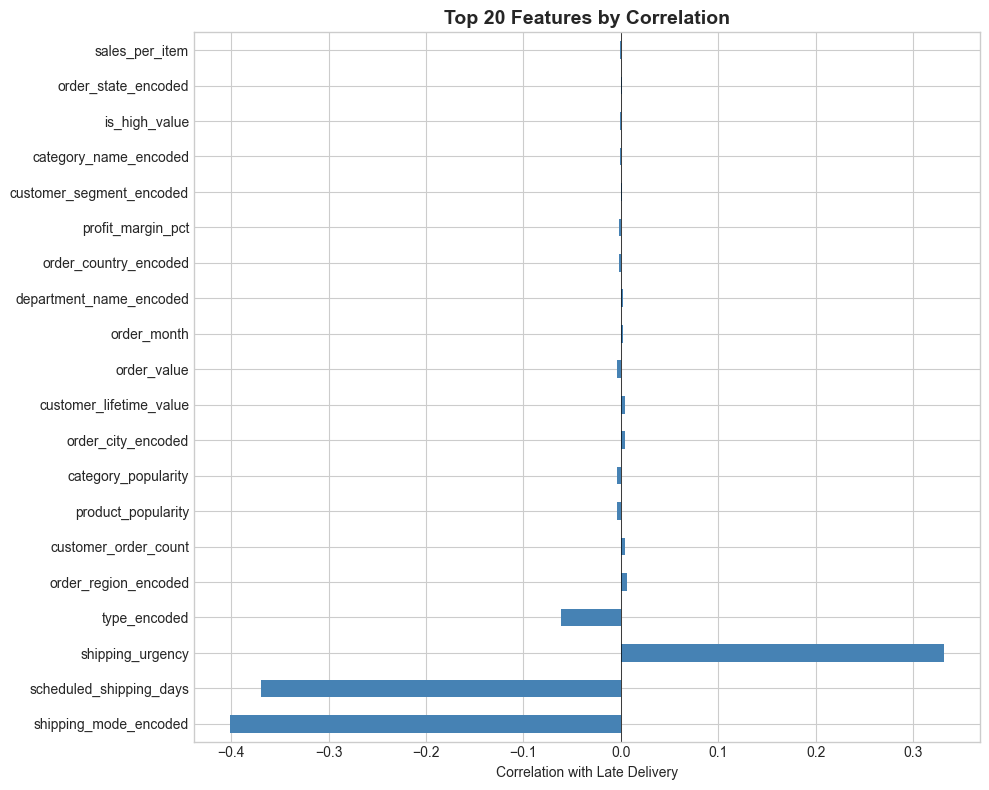


Top 10 correlated features:
shipping_mode_encoded     -0.401375
scheduled_shipping_days   -0.369352
shipping_urgency           0.331737
type_encoded              -0.061529
order_region_encoded       0.006159
customer_order_count       0.004593
product_popularity        -0.004219
category_popularity       -0.004007
order_city_encoded         0.003838
customer_lifetime_value    0.003730
dtype: float64

💡 INTERPRETATION:
   • Shipping-related features have highest predictive power
   • Days for shipment (scheduled) strongly negatively correlated


In [ ]:
# Feature Correlations with Target
correlations = X.corrwith(y).sort_values(key=abs, ascending=False)

fig = px.bar(
    x=correlations.head(15).values,
    y=correlations.head(15).index,
    orientation='h',
    title='<b>Top 15 Features by Correlation with Late Delivery</b>',
    labels={'x': 'Correlation', 'y': 'Feature'},
    color=correlations.head(15).values,
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0
)
fig.update_layout(height=500, yaxis={'categoryorder': 'total ascending'}, showlegend=False)
fig.show()

print("\n🎯 Top Predictors:")
for i, (feat, corr) in enumerate(correlations.head(5).items(), 1):
    direction = "↑ late" if corr > 0 else "↓ late"
    print(f"   {i}. {feat}: {corr:.3f} ({direction})")


In [ ]:
# Summary
print("=" * 50)
print("✅ FEATURE ENGINEERING COMPLETE")
print("=" * 50)
print(f"""
📊 Output Summary:
   • Features: {X.shape[1]} (all leakage-free)
   • Samples: {X.shape[0]:,}
   • Target: {y.mean()*100:.1f}% late delivery rate

🎯 Key Features for Prediction:
   • shipping_mode_encoded (strongest)
   • scheduled_shipping_days
   • shipping_urgency

⚠️  Excluded Leaky Features:
   • delivery_status, days_for_shipping_(real)
""")
print("➡️ Next: Run 04_model_evaluation.ipynb")



✅ Feature engineering complete!
   • 26 features created for 180,519 samples

➡️ Next: Run 05_classification_modeling.ipynb
